In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# ==========================================================
# 1. DATA PREPARATION & SLICING
# ==========================================================
# Load dataset
df = pd.read_csv('structural_full_68_68_16_edited.csv')

# --- Feature Extraction ---
# Whole-brain morphometry: 8th column (index 7) to end
X_morph = df.iloc[:, 7:].values
morph_features = df.columns[7:].tolist()

# Biological & Technical Confounders (to regress out)
X_nuisance = df[['age', 'sex', 'eTIV']].values

# Clinical / Experimental Predictors (kept intact)
X_clinical = df[['vas_t0', 'treatment_group']].values

# Target Variable
y = df['vas_t1'].values


In [3]:

# ==========================================================
# 2. CROSS-VALIDATION PIPELINE (SVR + RESIDUALIZATION)
# ==========================================================
loo = LeaveOneOut()

y_true = []
y_pred = []
feature_weights = []

print(f"Starting LOOCV with SVR across {len(morph_features)} whole-brain features...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_morph)):
    # --- A. Split into Train / Test Folds ---
    X_m_train, X_m_test = X_morph[train_idx], X_morph[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # --- B. Nuisance Covariate Residualization ---
    # Fit linear regressor strictly on training fold
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_m_train)
    
    # Calculate residuals: Morphometry_clean = Morphometry_raw - Confounders_effect
    X_m_train_clean = X_m_train - nuisance_regressor.predict(X_n_train)
    X_m_test_clean = X_m_test - nuisance_regressor.predict(X_n_test)
    
    # --- C. Assemble Final Feature Set ---
    X_train_final = np.hstack([X_m_train_clean, X_c_train])
    X_test_final = np.hstack([X_m_test_clean, X_c_test])
    
    # --- D. Feature Scaling ---
    # SVR is highly sensitive to feature scales; Z-scoring is essential
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_final)
    X_test_scaled = scaler.transform(X_test_final)
    
    # --- E. SVR Hyperparameter Tuning via Inner CV ---
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1.0, 10.0],  # Regularization parameter
        'epsilon': [0.01, 0.1, 0.5, 1.0]     # Width of the loss tube
    }
    
    base_svr = SVR(kernel='linear')
    inner_cv = GridSearchCV(
        base_svr, 
        param_grid, 
        cv=3, 
        scoring='neg_mean_squared_error',
        n_jobs=1
    )
    inner_cv.fit(X_train_scaled, y_train)
    
    # --- F. Fit Best SVR Model & Predict ---
    best_svr = inner_cv.best_estimator_
    best_svr.fit(X_train_scaled, y_train)
    
    pred = best_svr.predict(X_test_scaled)
    
    y_true.append(y_test[0])
    y_pred.append(pred[0])
    feature_weights.append(best_svr.coef_[0])  # Linear SVR feature coefficients

Starting LOOCV with SVR across 152 whole-brain features...



In [4]:
feature_weights

[array([-6.58520481e-03,  5.32970210e-03, -1.31483541e-03,  2.21024801e-03,
        -2.95387052e-03, -3.72726614e-03,  3.45559961e-03, -1.01159406e-02,
         4.27056692e-03, -2.03395839e-03, -4.85354353e-03, -1.94761059e-03,
         3.27084013e-05, -6.10912993e-03, -1.84839339e-03,  4.04728911e-04,
         3.17361274e-03, -4.54645833e-03, -3.37202140e-03,  1.94003074e-03,
         8.84235936e-03,  1.36922531e-03,  8.23608629e-04,  2.40579976e-03,
         4.49150496e-03, -6.73124276e-03, -9.04554959e-03,  4.23289871e-03,
         3.23832547e-04,  6.48145564e-03, -1.06862886e-03, -3.00773599e-03,
         3.41485582e-03, -4.53044776e-03,  2.25846791e-03,  5.10778968e-03,
        -2.50393140e-03, -3.71962821e-03, -1.00106013e-02, -1.57205702e-03,
        -3.44563486e-04, -5.70183168e-03,  5.19913758e-03,  1.65168708e-03,
         2.88003573e-03, -3.65128978e-03,  5.08125997e-03, -5.17075172e-03,
         8.94356038e-05,  1.17383205e-03, -6.54217959e-03,  2.09451023e-03,
        -6.6

In [ ]:

# ==========================================================
# 3. EVALUATION & SUBGROUP PERFORMANCE
# ==========================================================
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- Overall Metrics ---
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
corr = np.corrcoef(y_true, y_pred)[0, 1]

print("================ OVERALL SVR EVALUATION ================")
print(f"Mean Squared Error (MSE)   : {mse:.4f}")
print(f"Root Mean Squared Error    : {rmse:.4f}")
print(f"R-squared (R^2) Score      : {r2:.4f}")
print(f"Pearson Correlation (r)    : {corr:.4f}")
print("========================================================")

# --- Subgroup Evaluation: Active (2) vs. Sham (1) ---
treatment_vec = df['treatment_group'].values
active_mask = (treatment_vec == 2)
sham_mask = (treatment_vec == 1)

# Active Group
y_true_act, y_pred_act = y_true[active_mask], y_pred[active_mask]
r2_act, corr_act = r2_score(y_true_act, y_pred_act), np.corrcoef(y_true_act, y_pred_act)[0, 1]
rmse_act = np.sqrt(mean_squared_error(y_true_act, y_pred_act))

# Sham Group
y_true_shm, y_pred_shm = y_true[sham_mask], y_pred[sham_mask]
r2_shm, corr_shm = r2_score(y_true_shm, y_pred_shm), np.corrcoef(y_true_shm, y_pred_shm)[0, 1]
rmse_shm = np.sqrt(mean_squared_error(y_true_shm, y_pred_shm))

print("\n================ SUBGROUP PERFORMANCE ================")
print(f"ACTIVE GROUP [2] (N = {np.sum(active_mask)}): R^2 = {r2_act:.4f} | r = {corr_act:.4f} | RMSE = {rmse_act:.4f}")
print(f"SHAM GROUP   [1] (N = {np.sum(sham_mask)}): R^2 = {r2_shm:.4f} | r = {corr_shm:.4f} | RMSE = {rmse_shm:.4f}")
print("======================================================")

# --- Feature Importance Report ---
all_features = morph_features + ['vas_t0', 'treatment_group']
avg_weights = np.mean(feature_weights, axis=0)

weights_df = pd.DataFrame({
    'Feature': all_features,
    'Avg_SVR_Weight': avg_weights,
    'Abs_Weight': np.abs(avg_weights)
}).sort_values(by='Abs_Weight', ascending=False)

print("\n--- Top 15 Predictive Features (Linear SVR Weights) ---")
print(weights_df[['Feature', 'Avg_SVR_Weight']].head(15).to_string(index=False))

================ OVERALL SVR EVALUATION ================
Mean Squared Error (MSE)   : 6.2768
Root Mean Squared Error    : 2.5053
R-squared (R^2) Score      : -0.1062
Pearson Correlation (r)    : -0.0352

================ SUBGROUP PERFORMANCE ================
ACTIVE GROUP [2] (N = 25): R^2 = -0.1429 | r = -0.2623 | RMSE = 2.4673
SHAM GROUP   [1] (N = 20): R^2 = -0.1311 | r = 0.4225 | RMSE = 2.5521

--- Top 15 Predictive Features (Linear SVR Weights) ---
                         Feature  Avg_SVR_Weight
                          vas_T0        0.034047
 lh_caudalanteriorcingulate_area        0.024558
             rh_entorhinal_thick       -0.024242
            rh_postcentral_thick        0.022347
        lh_lateraloccipital_area       -0.020476
            lh_postcentral_thick        0.019169
     rh_posteriorcingulate_thick        0.019095
        lh_superiorfrontal_thick       -0.017812
                 treatment_group       -0.016980
       lh_inferiortemporal_thick       -0.016948
    

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

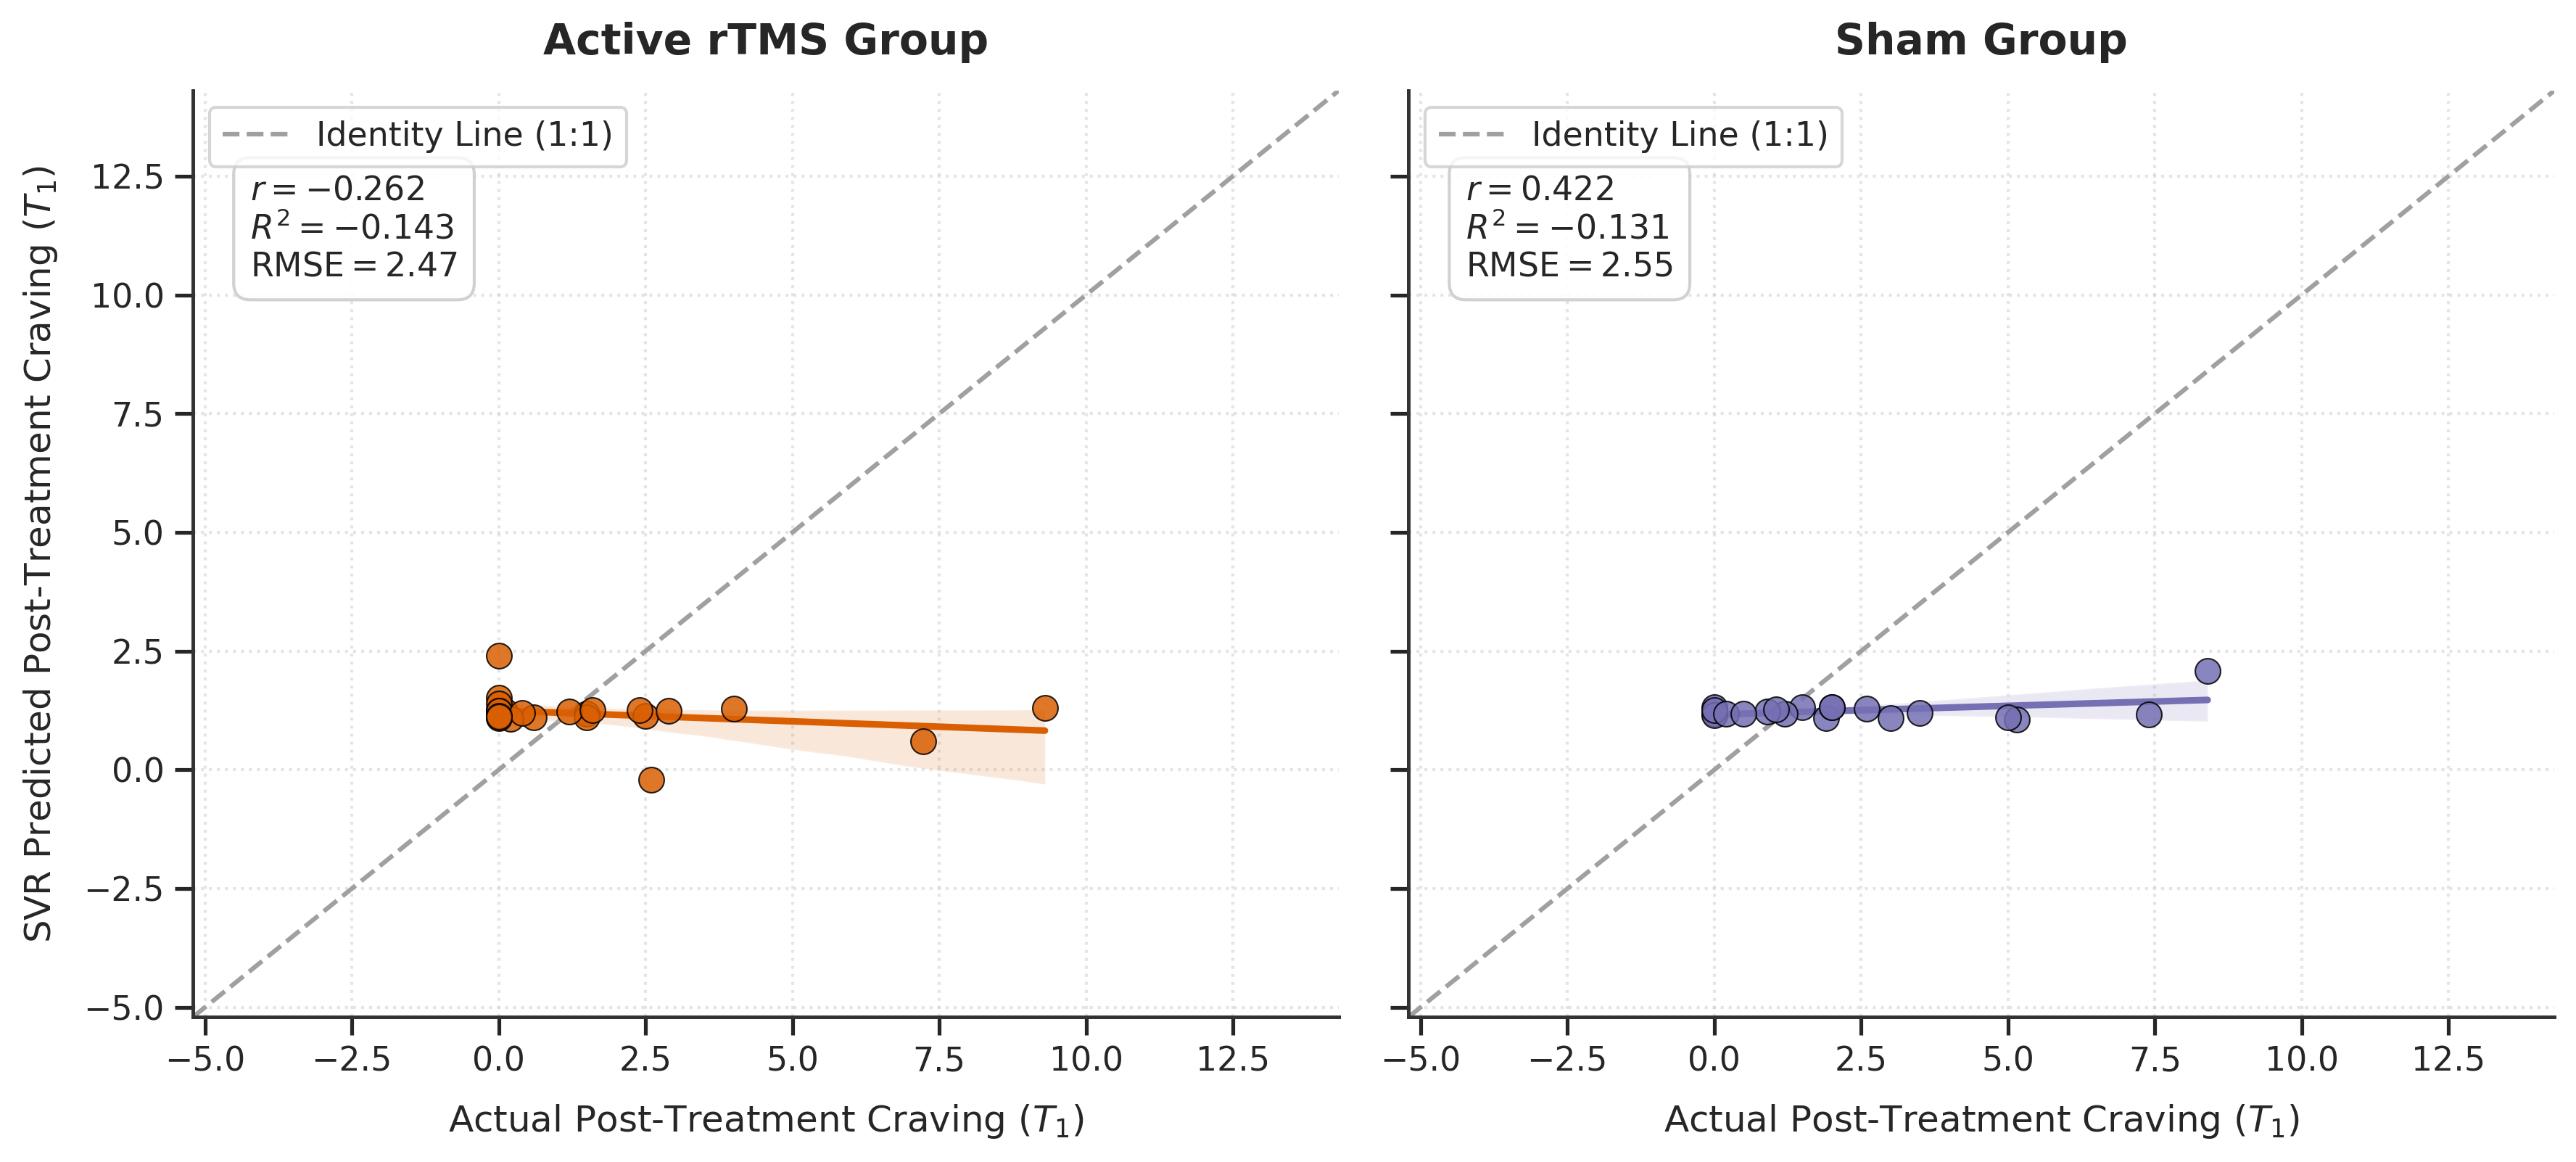

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set clean publication aesthetic
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

# 1. Map group codes (2 -> Active rTMS, 1 -> Sham)
plot_df = pd.DataFrame({
    'True_Craving': y_true,
    'Pred_Craving': y_pred,
    'Group': np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')
})

# 2. Setup figure canvas
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True, dpi=300)

palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'} # High-contrast colorblind-safe palette

groups = ['Active rTMS', 'Sham']
metrics = [
    {'r': corr_act, 'r2': r2_act, 'rmse': rmse_act},
    {'r': corr_shm, 'r2': r2_shm, 'rmse': rmse_shm}
]

# 3. Plot Active vs. Sham side-by-side
for i, grp in enumerate(groups):
    ax = axes[i]
    sub_df = plot_df[plot_df['Group'] == grp]
    m = metrics[i]
    color = palette[grp]
    
    # Draw 1:1 Identity Line (Perfect Prediction)
    min_val = min(plot_df['True_Craving'].min(), plot_df['Pred_Craving'].min()) - 5
    max_val = max(plot_df['True_Craving'].max(), plot_df['Pred_Craving'].max()) + 5
    ax.plot([min_val, max_val], [min_val, max_val], color='#A0A0A0', linestyle='--', linewidth=1.5, label='Identity Line (1:1)', zorder=1)
    
    # Scatter points for actual vs. predicted values
    sns.scatterplot(
        data=sub_df, x='True_Craving', y='Pred_Craving', 
        color=color, s=70, alpha=0.85, edgecolor='black', linewidth=0.5, ax=ax, zorder=3
    )
    
    # Linear Regression Fit with 95% Confidence Interval
    sns.regplot(
        data=sub_df, x='True_Craving', y='Pred_Craving', 
        ax=ax, scatter=False, color=color, line_kws={'linewidth': 2.2}, ci=95
    )
    
    # Formatting & Subgroup Titles
    ax.set_title(f'{grp} Group', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Actual Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
    if i == 0:
        ax.set_ylabel('SVR Predicted Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
    
    # Annotate statistical metrics inside each plot
    stats_text = f"$r = {m['r']:.3f}$\n$R^2 = {m['r2']:.3f}$\n$\mathrm{{RMSE}} = {m['rmse']:.2f}$"
    ax.text(
        0.05, 0.80, stats_text, transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#CCCCCC')
    )
    
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True, linestyle=':', alpha=0.5)

sns.despine()
plt.tight_layout()

# Save high-res figure for publication/manuscript
plt.savefig('SUDMEX_SVR_Prediction_Active_vs_Sham.png', dpi=300, bbox_inches='tight')
plt.show()